In [5]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import resample
from agents.ffnn_agent2 import FFNNAgent
from torch.utils.data import TensorDataset, DataLoader
import torch
import matplotlib.pyplot as plt
import random

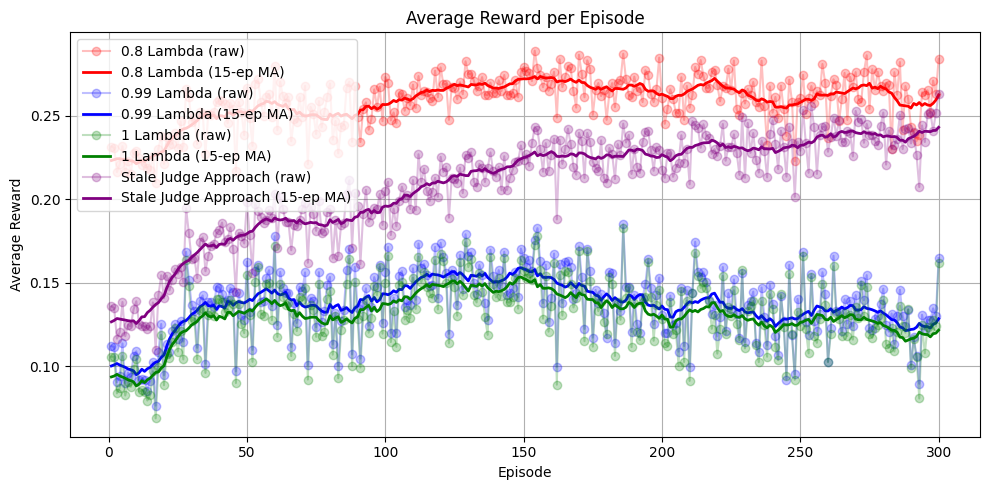

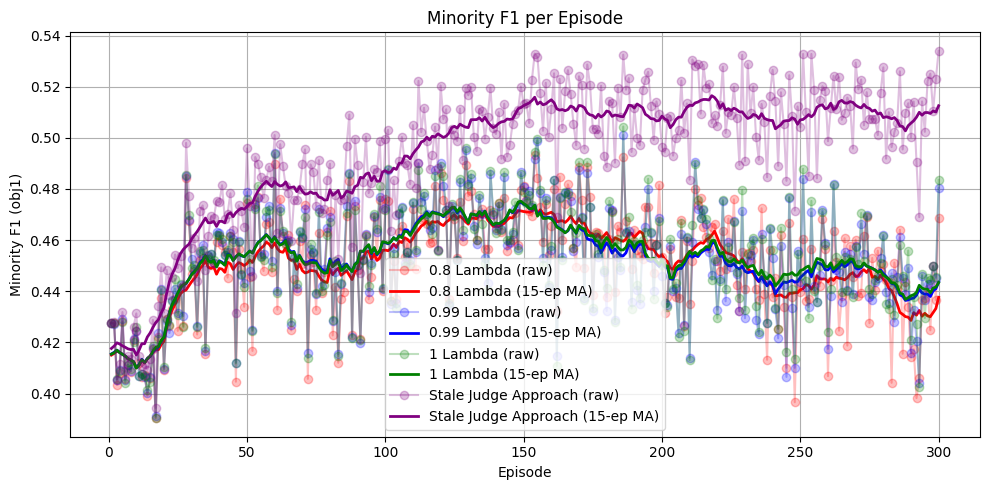

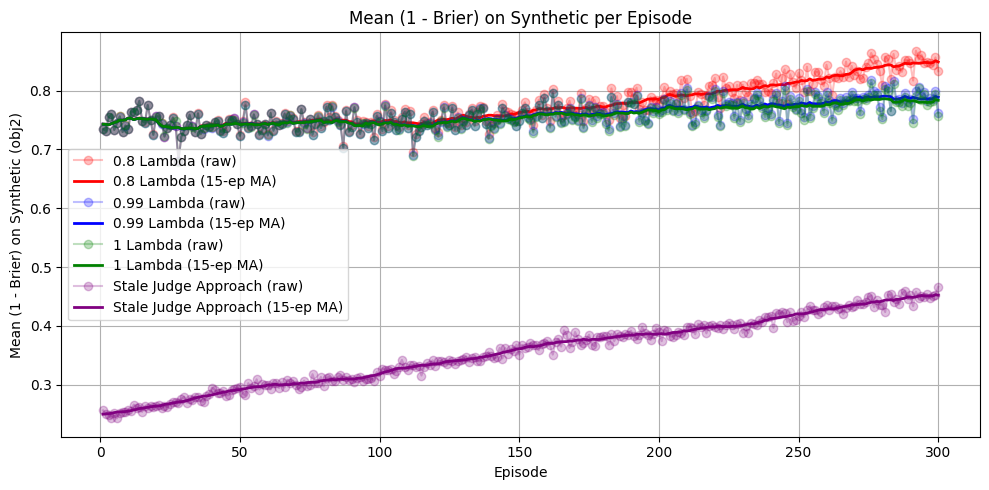

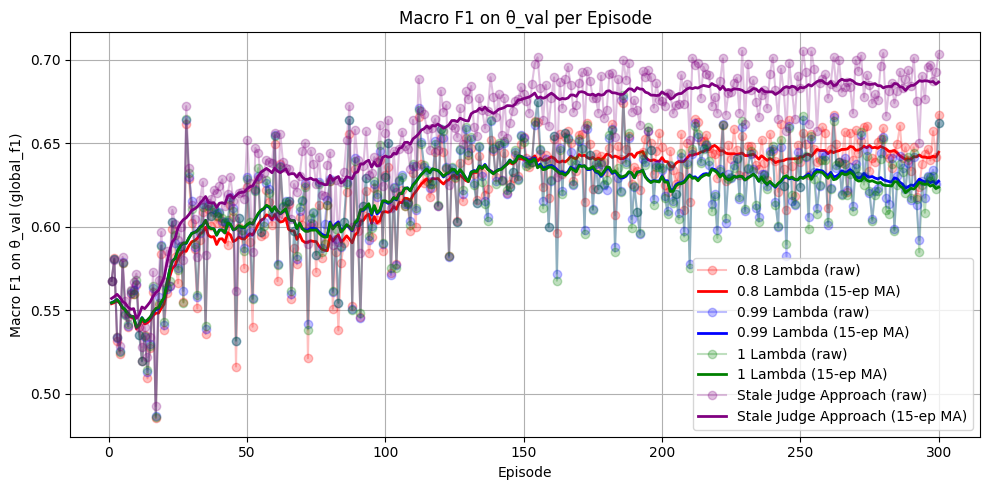

In [6]:
# --- Compare multiple runs on the same plot per metric ---

# The error is caused by a malformed tuple in the 'runs' list.
# Each entry in 'runs' should be a 3-tuple: (path, label, color).
# The last entry is missing a comma between the label and color, so Python concatenates the two strings,
# resulting in a 2-tuple instead of a 3-tuple. This causes unpacking to fail in the for-loop.

# List of runs to compare: (path, label, color)
runs = [
    (
        "training_runs/2025-08-14_17-16-17_EP300_TRJ2000_REAL3000_BIAS0.8_L0.8/",
        "0.8 Lambda",
        "red"
    ),
    (
        "training_runs/2025-08-14_17-52-59_EP300_TRJ2000_REAL3000_BIAS0.8_L0.99/",
        "0.99 Lambda",
        "blue"
    ),
    (
        "training_runs/2025-08-14_18-06-05_EP300_TRJ2000_REAL3000_BIAS0.8_L1/",
        "1 Lambda",
        "green"
    ),
    (
        "training_runs/2025-08-20_12-57-57_EP300_TRJ2000_REAL3000_BIAS0.8_L0.8/",
        "Stale Judge Approach",  # This run used alpha the entire time.
        "Purple"
    ),
    # (
    #     "training_runs/2025-08-20_16-28-47_EP300_TRJ2000_REAL3000_BIAS0.8_L0.8/",
    #     "Stale Judge Approach (1000 eps)",#This run also uses alpha and shows the individual reward still eventually dominates and causes adverse affects
    #     "orange"
    # )
]

# Metric configs: (column, ylabel, title)
metric_configs = [
    ('average_reward', 'Average Reward', 'Average Reward per Episode'),
    ('obj1_minority_f1', 'Minority F1 (obj1)', 'Minority F1 per Episode'),
    ('obj2_mean', 'Mean (1 - Brier) on Synthetic (obj2)', 'Mean (1 - Brier) on Synthetic per Episode'),
    ('global_f1', 'Macro F1 on θ_val (global_f1)', 'Macro F1 on θ_val per Episode'),
]

window = 15

# Read all runs' metrics into a list of dicts: {label, color, df}
run_metrics = []
for path, label, color in runs:
    try:
        df = pd.read_csv(path + 'metrics.csv')
        # Coerce all metric columns to numeric
        for col in ['average_reward', 'obj1_minority_f1', 'obj2_mean', 'global_f1']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        run_metrics.append({'label': label, 'color': color, 'df': df})
    except Exception as e:
        print(f"Could not load metrics for {label} at {path}: {e}")

# Plot each metric, overlaying all runs
for col, ylabel, title in metric_configs:
    plt.figure(figsize=(10, 5))
    for run in run_metrics:
        df = run['df']
        label = run['label']
        color = run['color']
        # Compute moving average
        moving_avg = df[col].rolling(window=window, min_periods=1, center=True).mean()
        # Plot raw values (faint)
        plt.plot(df['episode'], df[col], marker='o', linestyle='-', alpha=0.25, color=color, label=f"{label} (raw)")
        # Plot moving average (bold)
        plt.plot(df['episode'], moving_avg, color=color, linewidth=2, label=f"{label} ({window}-ep MA)")
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


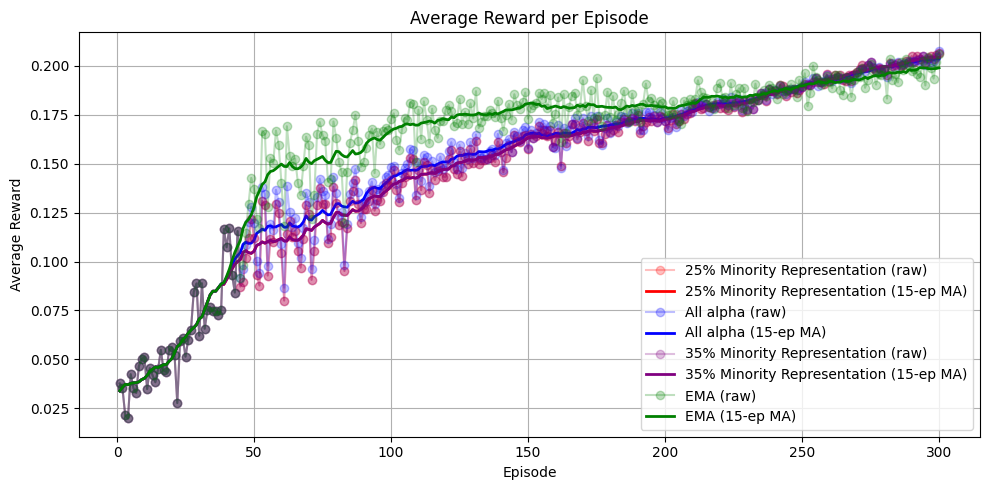

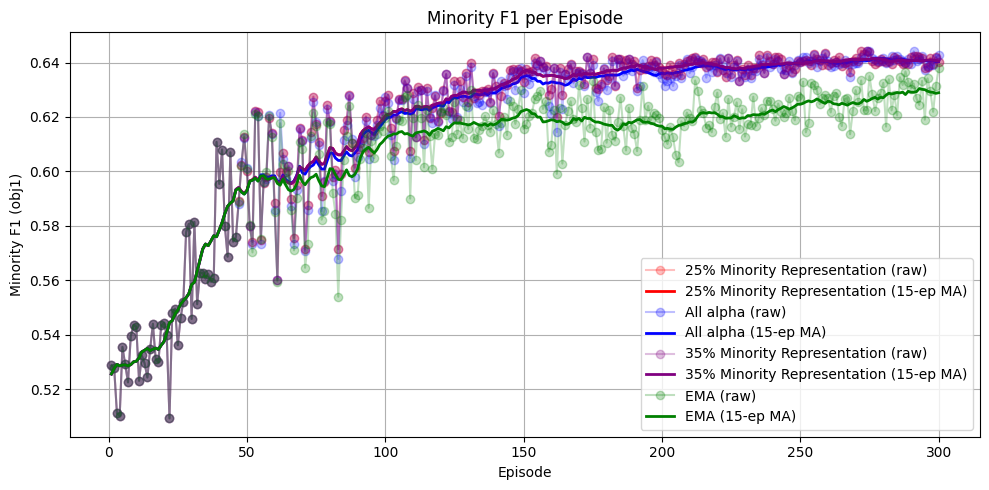

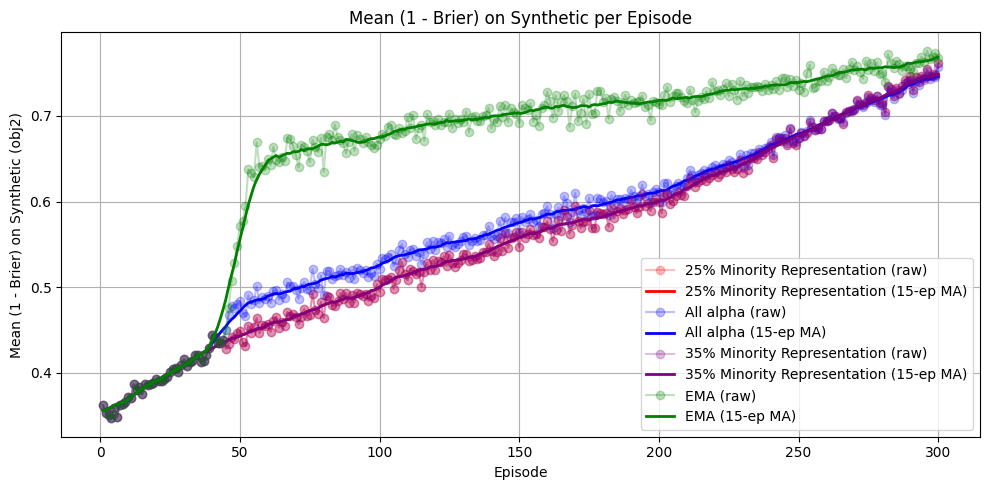

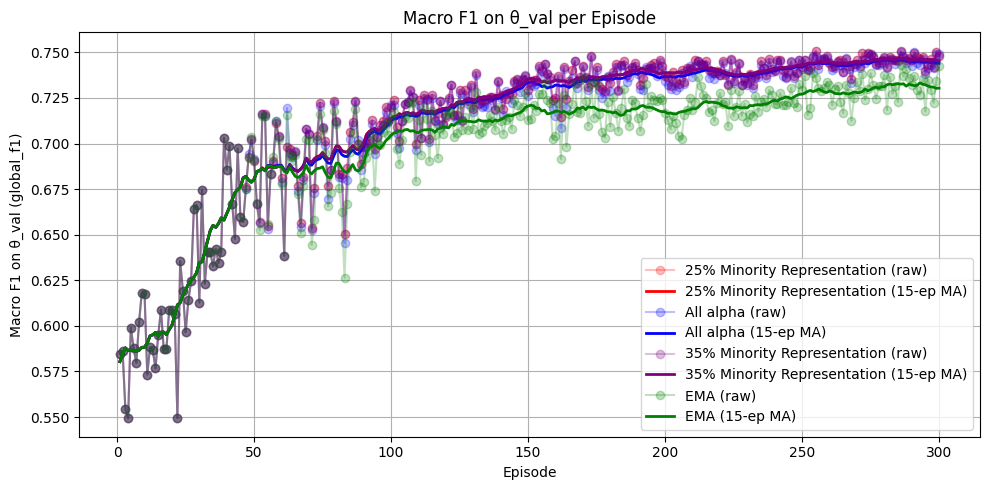

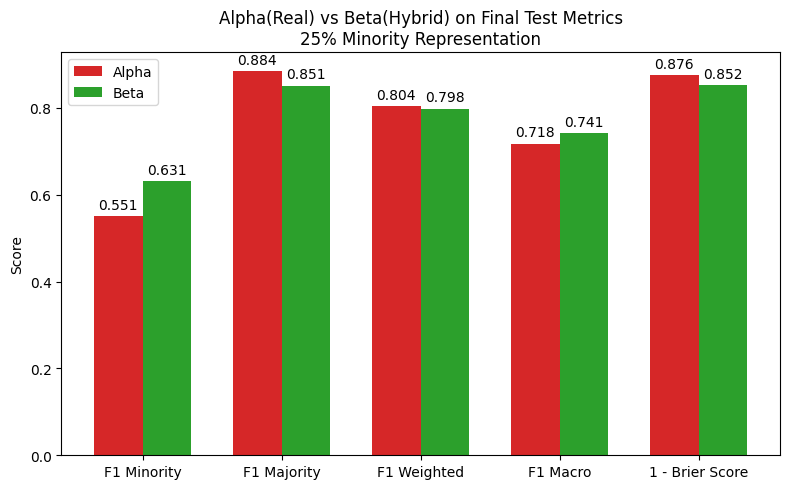

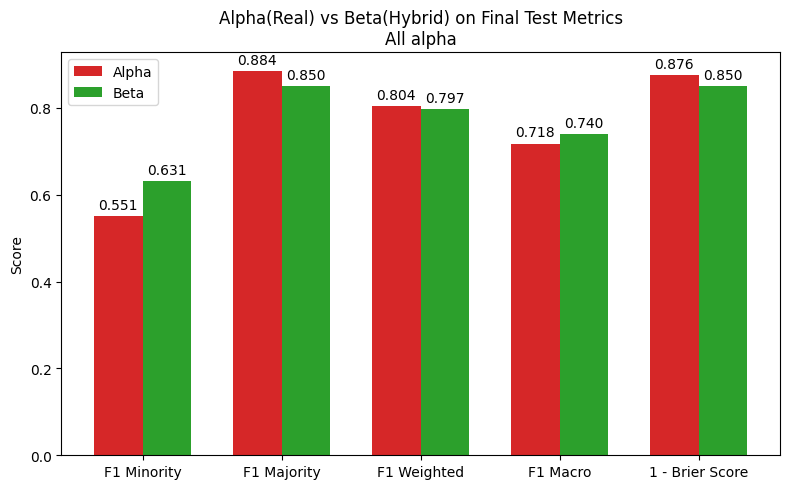

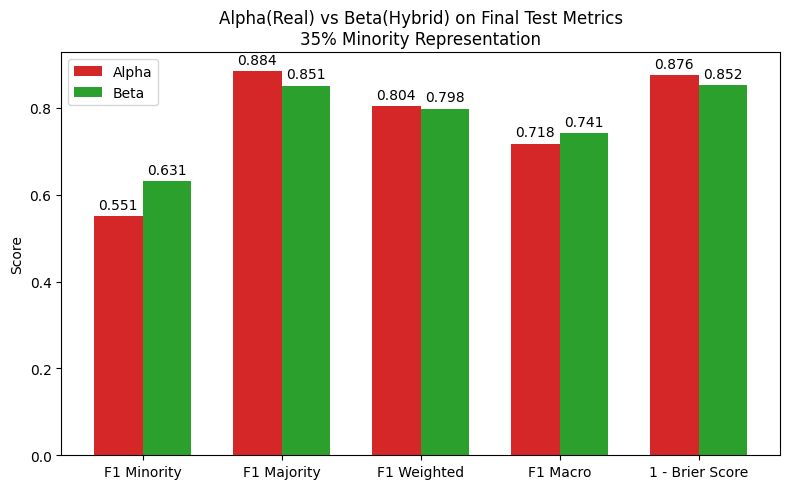

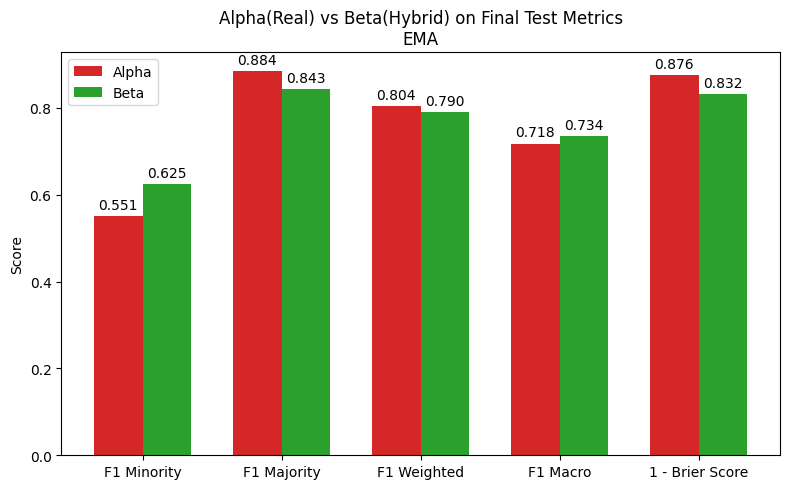

In [7]:
# --- Compare multiple runs on the same plot per metric ---
# In addition, plot bar graphs comparing alpha and beta models on each metric from final_test_metrics.csv per run.

# List of runs to compare: (path, label, color)
runs = [
    (
        "training_runs/2025-08-21_16-26-56_EP300_TRJ2000_REAL3000_BIAS0.25_L0.8/",
        "25% Minority Representation",
        "red"
    ),
    (
        "training_runs/2025-08-24_13-44-00_EP300_TRJ2000_REAL3000_BIAS0.35_L0.8/",
        "All alpha",
        "blue"
    ),
    (
        "training_runs/2025-08-21_17-14-48_EP300_TRJ2000_REAL3000_BIAS0.35_L0.8/",
        "35% Minority Representation",
        "purple"
    ),
    (
        "training_runs/2025-08-24_13-32-09_EP300_TRJ2000_REAL3000_BIAS0.35_L0.8/",
        "EMA",
        "green"
    )

]

# Metric configs: (column, ylabel, title)
metric_configs = [
    ('average_reward', 'Average Reward', 'Average Reward per Episode'),
    ('obj1_minority_f1', 'Minority F1 (obj1)', 'Minority F1 per Episode'),
    ('obj2_mean', 'Mean (1 - Brier) on Synthetic (obj2)', 'Mean (1 - Brier) on Synthetic per Episode'),
    ('global_f1', 'Macro F1 on θ_val (global_f1)', 'Macro F1 on θ_val per Episode'),
]

window = 15

# Read all runs' metrics into a list of dicts: {label, color, df}
run_metrics = []
for path, label, color in runs:
    try:
        df = pd.read_csv(path + 'metrics.csv')
        # Coerce all metric columns to numeric
        for col in ['average_reward', 'obj1_minority_f1', 'obj2_mean', 'global_f1']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        run_metrics.append({'label': label, 'color': color, 'df': df, 'path': path})
    except Exception as e:
        print(f"Could not load metrics for {label} at {path}: {e}")

# Plot each metric, overlaying all runs
for col, ylabel, title in metric_configs:
    plt.figure(figsize=(10, 5))
    for run in run_metrics:
        df = run['df']
        label = run['label']
        color = run['color']
        # Compute moving average
        moving_avg = df[col].rolling(window=window, min_periods=1, center=True).mean()
        # Plot raw values (faint)
        plt.plot(df['episode'], df[col], marker='o', linestyle='-', alpha=0.25, color=color, label=f"{label} (raw)")
        # Plot moving average (bold)
        plt.plot(df['episode'], moving_avg, color=color, linewidth=2, label=f"{label} ({window}-ep MA)")
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Bar plots comparing alpha and beta models on each metric from final_test_metrics.csv per run ---

# Metrics to compare from final_test_metrics.csv
# For brier, we will plot 1-brier so that higher is better (lower brier is better)
metrics = [
    ("f1_minority", "F1 Minority"),
    ("f1_majority", "F1 Majority"),
    ("f1_weighted", "F1 Weighted"),
    ("f1_macro", "F1 Macro"),
    ("brier", "1 - Brier Score"),
]

# For each run, load final_test_metrics.csv and plot bar graphs comparing alpha and beta
for run in run_metrics:
    path = run['path']
    label = run['label']
    color = run['color']
    final_csv = path + "final_test_metrics.csv"
    try:
        df_final = pd.read_csv(final_csv)
        # Use the last row (should be only one row, but just in case)
        row = df_final.iloc[-1]
        # Prepare data for bar plot: for each metric, show alpha and beta side by side
        alpha_vals = []
        beta_vals = []
        for m, _ in metrics:
            if m == "brier":
                # For brier, use 1-brier (higher is better)
                alpha_val = 1.0 - row["alpha_brier"]
                beta_val  = 1.0 - row["beta_brier"]
            else:
                alpha_val = row[f"alpha_{m}"]
                beta_val  = row[f"beta_{m}"]
            alpha_vals.append(alpha_val)
            beta_vals.append(beta_val)
        x = np.arange(len(metrics))
        width = 0.35

        plt.figure(figsize=(8, 5))
        bars_alpha = plt.bar(x - width/2, alpha_vals, width, label='Alpha', color='tab:red')
        bars_beta  = plt.bar(x + width/2, beta_vals,  width, label='Beta', color='tab:green')
        plt.xticks(x, [m[1] for m in metrics])
        plt.ylabel("Score")
        plt.title(f"Alpha(Real) vs Beta(Hybrid) on Final Test Metrics\n{label}")
        plt.legend()
        plt.tight_layout()

        # Add value labels on top of bars
        def autolabel(bars, values):
            for bar, val in zip(bars, values):
                height = bar.get_height()
                plt.annotate(f'{val:.3f}',
                             xy=(bar.get_x() + bar.get_width() / 2, height),
                             xytext=(0, 3),  # 3 points vertical offset
                             textcoords="offset points",
                             ha='center', va='bottom', fontsize=10)

        autolabel(bars_alpha, alpha_vals)
        autolabel(bars_beta, beta_vals)

        plt.show()
    except Exception as e:
        print(f"Could not load or plot final_test_metrics.csv for {label} at {path}: {e}")




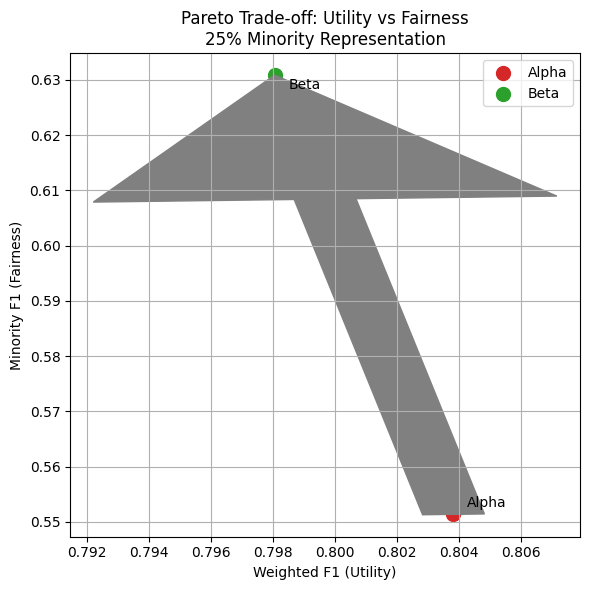

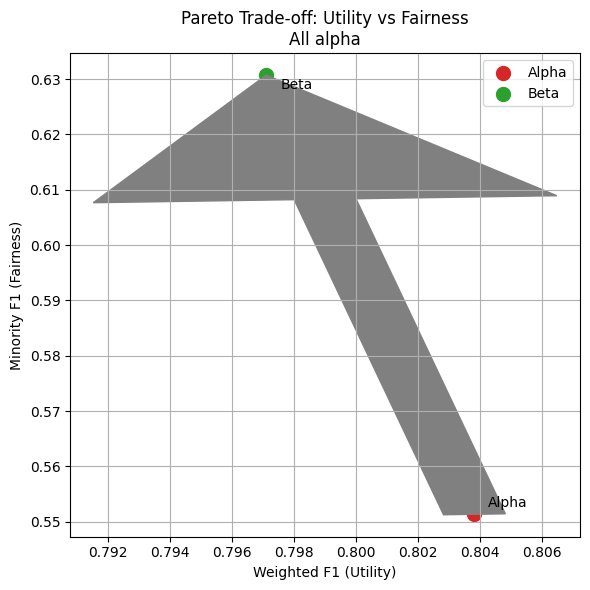

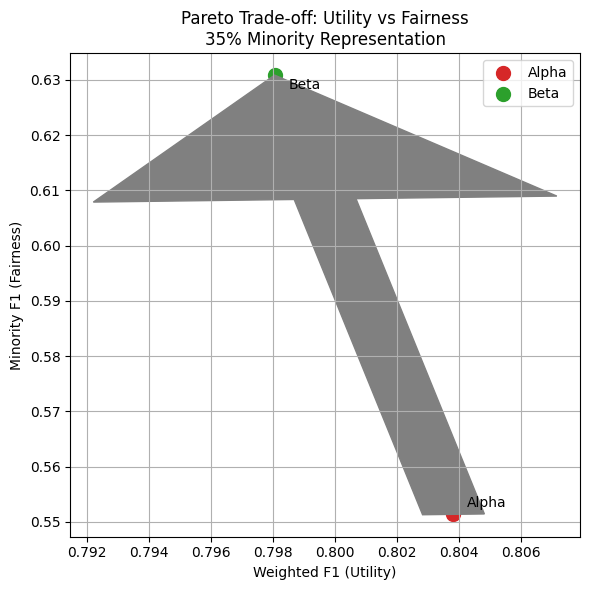

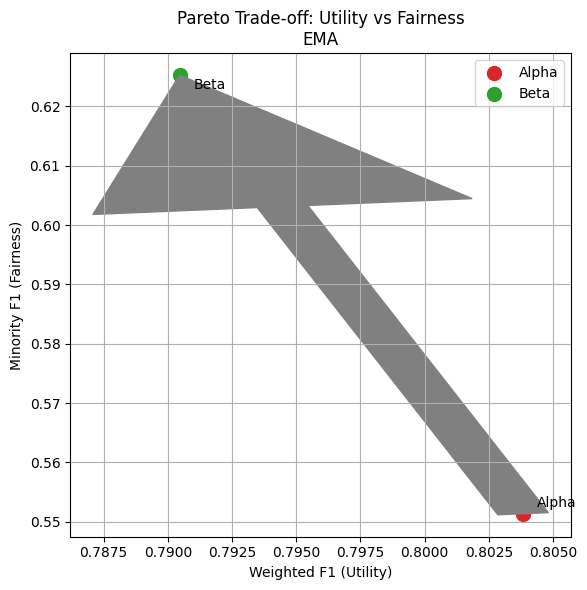

In [8]:
# --- Pareto frontier style plot: Weighted F1 vs Minority F1 for Alpha vs Beta ---

for run in run_metrics:
    path = run['path']
    label = run['label']
    final_csv = path + "final_test_metrics.csv"
    try:
        df_final = pd.read_csv(final_csv)
        row = df_final.iloc[-1]

        # Extract Alpha and Beta scores
        alpha_minority = row["alpha_f1_minority"]
        beta_minority  = row["beta_f1_minority"]
        alpha_weighted = row["alpha_f1_weighted"]
        beta_weighted  = row["beta_f1_weighted"]

        plt.figure(figsize=(6, 6))
        plt.scatter(alpha_weighted, alpha_minority, color="tab:red", marker="o", s=100, label="Alpha")
        plt.scatter(beta_weighted, beta_minority,   color="tab:green", marker="o", s=100, label="Beta")

        # Annotate the points
        plt.annotate("Alpha", (alpha_weighted, alpha_minority), textcoords="offset points", xytext=(10, 5))
        plt.annotate("Beta",  (beta_weighted,  beta_minority),  textcoords="offset points", xytext=(10, -10))

        # Draw arrows to show trade-off direction
        plt.arrow(alpha_weighted, alpha_minority,
                  beta_weighted - alpha_weighted,
                  beta_minority - alpha_minority,
                  color="gray", width=0.002, head_width=0.015, length_includes_head=True)

        plt.xlabel("Weighted F1 (Utility)")
        plt.ylabel("Minority F1 (Fairness)")
        plt.title(f"Pareto Trade-off: Utility vs Fairness\n{label}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not load Pareto plot for {label} at {path}: {e}")
